# 06 · Systems of ordinary differential equations

Coupled equations, one per variable. A run returns a system; it counts as correct
only when every equation is correct. For chaotic systems the integrated solution
follows the data only for a limited time: small differences in coefficients and
in the initial state grow exponentially.

**How to read the comparison.** The upper panel puts the left-hand side of the
selected equation, computed from the data, next to the value the equation
predicts from its right-hand side. For ordinary differential equations written
as "highest derivative = function of the state", the lower panel integrates the
equation from the first point of the record and compares the solution with the
data; there errors accumulate, so this is the stricter test. When the selected
equation is not of that form, only the upper panel is shown. A close match of the
two sides alone does not prove the law: an identity of the record or a rearranged
equation can match as well, so the set of terms is compared with the known law
separately.

Displayed outputs are saved examples from earlier executions and do not verify the current version. Re-execute the relevant cells to obtain current results. Searches may reuse a compatible saved run; the printed status identifies this. Recovered laws are established by the reported term comparison, rather than by the presence of a plotted equation.

In [1]:
import os, sys, time
from pathlib import Path
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')   # before numpy: EPDE is faster single-threaded
os.environ.setdefault('OMP_NUM_THREADS', '1')

# find projects/pic (this notebook lives in projects/pic/notebooks)
PIC = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'epde_bench').is_dir())
sys.path[:0] = [str(PIC.parent.parent), str(PIC)]
import epde

import numpy as np
import matplotlib.pyplot as plt
from epde_bench import datasets, metrics, load_config, resolve_for_problem, discover
from epde_bench.plotting import plot_problem, plot_front
from epde_bench.truthcheck import check, print_check
from epde_bench.nbcache import cached_run, print_run
from epde_bench.reconstruction import plot_reconstruction
%matplotlib inline
print('EPDE imported; notebook environment ready')

EPDE imported; notebook environment ready


## Lotka–Volterra predator–prey model

$$u' = \alpha u - \beta u v, \qquad v' = \delta u v - \gamma v,$$

all four parameters equal to 20.

lv: Lotka-Volterra predator-prey
  class: system of ODEs, source: synthetic
  axes: t; data shape: (301,); variables: u, v
  t: [0, 0.9967], 301 points
  truth:
    20.0 * u{power: 1.0} + -20.0 * u{power: 1.0} * v{power: 1.0} = du/dx0{power: 1.0}
    20.0 * u{power: 1.0} * v{power: 1.0} + -20.0 * v{power: 1.0} = dv/dx0{power: 1.0}
  + 1 equivalent form(s)
  notes: alpha = beta = gamma = delta = 20, all 301 samples: with only the first half of the record the system is not identifiable.


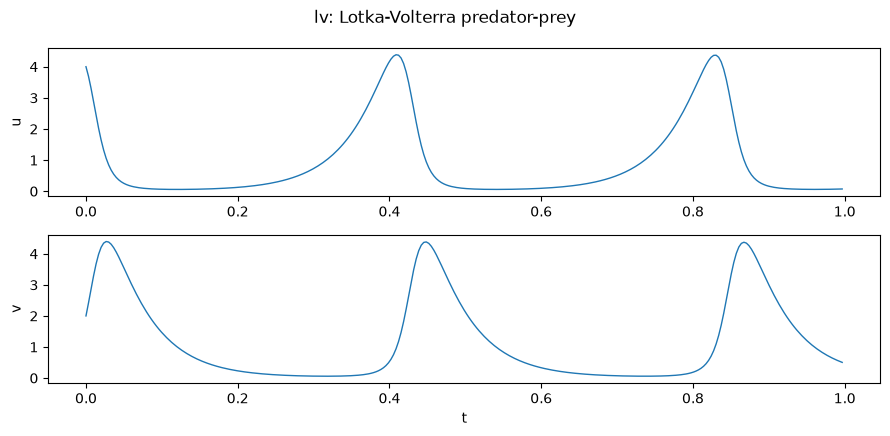

In [2]:
p = datasets.load('lv')
print(p.summary())
plot_problem(p); plt.show()

In [3]:
p, report = check('lv', noise_levels=[0, 1, 5])
print_check(p, report)

lv: Lotka-Volterra predator-prey
  class: system of ODEs, source: synthetic
  axes: t; data shape: (301,); variables: u, v
  t: [0, 0.9967], 301 points
  truth:
    20.0 * u{power: 1.0} + -20.0 * u{power: 1.0} * v{power: 1.0} = du/dx0{power: 1.0}
    20.0 * u{power: 1.0} * v{power: 1.0} + -20.0 * v{power: 1.0} = dv/dx0{power: 1.0}
  + 1 equivalent form(s)
  notes: alpha = beta = gamma = delta = 20, all 301 samples: with only the first half of the record the system is not identifiable.

=== noise 0 % ===
R^2 of the true structure: 0.999972   (du/dx0{power: 1.0})
  term                                                             true       fitted  R^2 lost if dropped
  u{'power': 1.0}                                                    20       19.914            3.380e-01
  u{'power': 1.0} * v{'power': 1.0}                                 -20      -19.893            1.000e+00
R^2 of the true structure: 0.999973   (dv/dx0{power: 1.0})
  term                                                 

In [4]:
rec = cached_run('lv', variant='default', noise=0.0, seed=0)
print_run(rec)

ok fit 105 s (from cache)
[0]
     / 574.0711551499951 * u{power: 2.0} + 32.913534714925866 * v{power: 3.0} + 106.78063524268043 * dv/dx0{power: 1.0} * u{power: 1.0} + -24.55318640841926 * u{power: 2.0} * dv/dx0{power: 1.0} + -0.9171472684603138 * du/dx0{power: 1.0} * v{power: 2.0} + -125.32374911928117 * u{power: 3.0} + 0.0 = du/dx0{power: 2.0}
     \ 19.985447101796716 * u{power: 1.0} + -0.9999288914515424 * du/dx0{power: 1.0} + -19.992597643626127 * v{power: 1.0} + 0.0 = dv/dx0{power: 1.0}
[1] <- compromise pick
     / -19.893298642850297 * v{power: 1.0} * u{power: 1.0} + 19.914775714713457 * u{power: 1.0} + 0.0 = du/dx0{power: 1.0}
     \ 3.2013829937552 * u{power: 2.0} * dv/dx0{power: 1.0} + 0.0490960001606712 * du/dx0{power: 1.0} * u{power: 3.0} + 23.805661405052657 * du/dx0{power: 1.0} * v{power: 1.0} + 369.71749753727323 * v{power: 2.0} + -1.1322844471556817 * du/dx0{power: 1.0} * dv/dx0{power: 1.0} + 0.0 = dv/dx0{power: 2.0}
[2]
     / -0.31691067684892676 * du/dx0{power: 1.0}

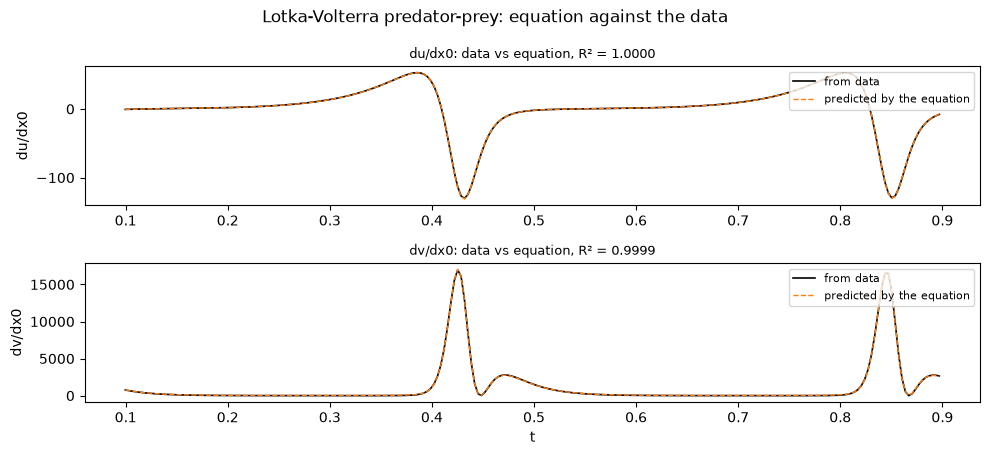

{'du/dx0{power: 1.0}': 1.0, 'dv/dx0{power: 2.0}': 0.9999}


In [5]:
problem = datasets.load('lv')
search_cfg = resolve_for_problem(load_config('lv'), problem)
if rec['status'] == 'ok' and rec.get('selected'):
    fig, scores = plot_reconstruction(problem, rec['selected'], search_cfg)
    plt.show()
    print({k: round(v, 4) for k, v in scores.items()})

In [6]:
rec = cached_run('lv', variant='default', noise=5.0, seed=0)
print_run(rec)

ok fit 87 s (from cache)
[0]
     / -0.04111233451768855 * u{power: 2.0} * dv/dx0{power: 1.0} + 17.03813281833266 * u{power: 1.0} + -4.3726802291195614 * v{power: 2.0} * u{power: 1.0} + 0.0 = du/dx0{power: 1.0}
     \ 14.434363037835954 * v{power: 1.0} * u{power: 2.0} + -0.7729419420722046 * v{power: 3.0} * sin{power: 1.0, freq: 2.0, dim: 0.0} + 0.0 = dv/dx0{power: 1.0} * u{power: 1.0}
[1]
     / 6.760056945376658 * u{power: 2.0} * x{power: 1.0, dim: 0.0} + -17.159110534061433 * v{power: 1.0} * u{power: 1.0} + 0.0 = du/dx0{power: 1.0}
     \ 14.711102856030166 * u{power: 2.0} * v{power: 1.0} + -0.6119492649475099 * v{power: 3.0} + 0.1896865375601824 * x{power: 1.0, dim: 0.0} * du/dx0{power: 1.0} + 0.0 = u{power: 1.0} * dv/dx0{power: 1.0}
[2] <- compromise pick
     / 16.9722767570719 * u{power: 1.0} + 0.4119159557402334 * u{power: 3.0} * v{power: 3.0} + -5.752332924525008 * u{power: 2.0} * v{power: 2.0} + 0.0 = du/dx0{power: 1.0}
     \ -18.239125649924574 * u{power: 3.0} * v{power: 3.

## Lorenz system

$$u' = \sigma (v - u),\quad v' = u(\rho - w) - v,\quad w' = uv - \beta w,$$

with $\sigma = 10$, $\rho = 28$, $\beta = 8/3$.

lorenz: Lorenz-63 system
  class: system of ODEs, source: synthetic
  axes: t; data shape: (1041,); variables: u, v, w
  t: [0, 5.2], 1041 points
  truth:
    10.0 * v{power: 1.0} + -10.0 * u{power: 1.0} = du/dx0{power: 1.0}
    28.0 * u{power: 1.0} + -1.0 * u{power: 1.0} * w{power: 1.0} + -1.0 * v{power: 1.0} = dv/dx0{power: 1.0}
    1.0 * u{power: 1.0} * v{power: 1.0} + -2.6666666666666665 * w{power: 1.0} = dw/dx0{power: 1.0}
  notes: sigma = 10, rho = 28, beta = 8/3. Window t in [20.0, 25.2] of the stored run, every 5th sample: on the attractor, not the initial transient.


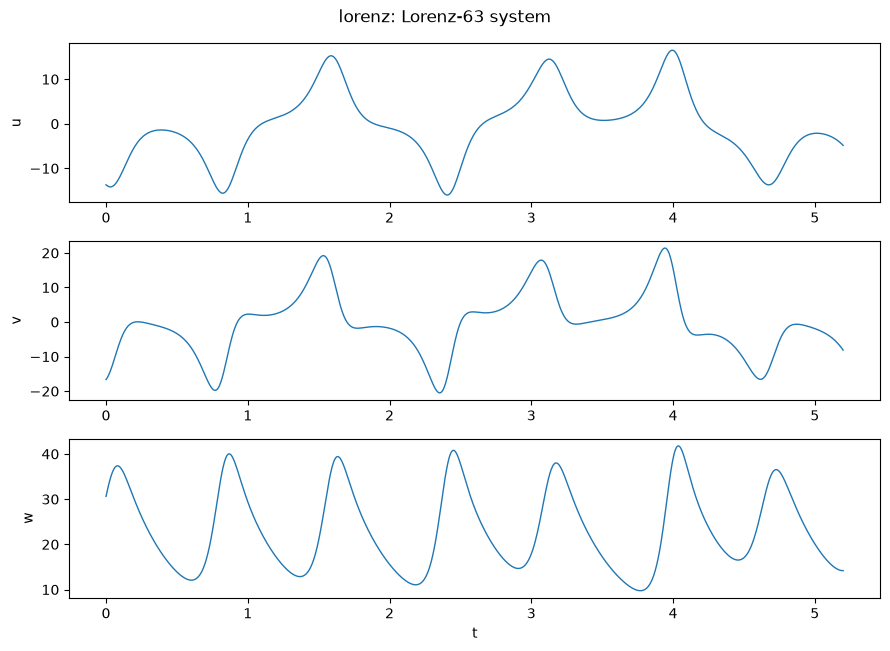

In [7]:
p = datasets.load('lorenz')
print(p.summary())
plot_problem(p); plt.show()

In [8]:
p, report = check('lorenz', noise_levels=[0, 1, 5])
print_check(p, report)

lorenz: Lorenz-63 system
  class: system of ODEs, source: synthetic
  axes: t; data shape: (1041,); variables: u, v, w
  t: [0, 5.2], 1041 points
  truth:
    10.0 * v{power: 1.0} + -10.0 * u{power: 1.0} = du/dx0{power: 1.0}
    28.0 * u{power: 1.0} + -1.0 * u{power: 1.0} * w{power: 1.0} + -1.0 * v{power: 1.0} = dv/dx0{power: 1.0}
    1.0 * u{power: 1.0} * v{power: 1.0} + -2.6666666666666665 * w{power: 1.0} = dw/dx0{power: 1.0}
  notes: sigma = 10, rho = 28, beta = 8/3. Window t in [20.0, 25.2] of the stored run, every 5th sample: on the attractor, not the initial transient.

=== noise 0 % ===
R^2 of the true structure: 1.000000   (du/dx0{power: 1.0})
  term                                                             true       fitted  R^2 lost if dropped
  v{'power': 1.0}                                                    10       9.9945            9.977e-01
  u{'power': 1.0}                                                   -10      -9.9944            7.726e-01
R^2 of the true struct

In [9]:
rec = cached_run('lorenz', variant='default', noise=0.0, seed=0)
print_run(rec)

ok fit 450 s (from cache)
[0]
     / 0.00879993242379217 * v{power: 3.0} + 0.0 = du/dx0{power: 1.0}
     | 0.6041386315804707 * v{power: 3.0} + -0.06248936354384751 * u{power: 3.0} * w{power: 1.0} + 0.0 = dv/dx0{power: 1.0} * w{power: 1.0}
     \ 0.00183514436568406 * v{power: 3.0} * u{power: 3.0} + 0.0 = dw/dx0{power: 2.0}
[1]
     / -9.994429205124053 * u{power: 1.0} + 9.994478222808224 * v{power: 1.0} + 0.0 = du/dx0{power: 1.0}
     | 0.028867687204828036 * v{power: 3.0} + -0.07194316498511477 * u{power: 3.0} + 0.0 = dv/dx0{power: 1.0}
     \ 1.5113452051020855 * u{power: 2.0} + -0.00300907479435336 * w{power: 3.0} + -0.057291617256933644 * w{power: 2.0} + 0.0 = dw/dx0{power: 1.0}
[2]
     / 0.009732793962379667 * w{power: 3.0} + -7.6692920002618035 * u{power: 2.0} + 6.258679029607694 * v{power: 2.0} + 0.0 = v{power: 1.0} * du/dx0{power: 1.0}
     | -3.223262801877964e-05 * w{power: 2.0} * u{power: 3.0} + 0.0 = dv/dx0{power: 1.0}
     \ 1.4547440390356714 * u{power: 2.0} + -0.153072

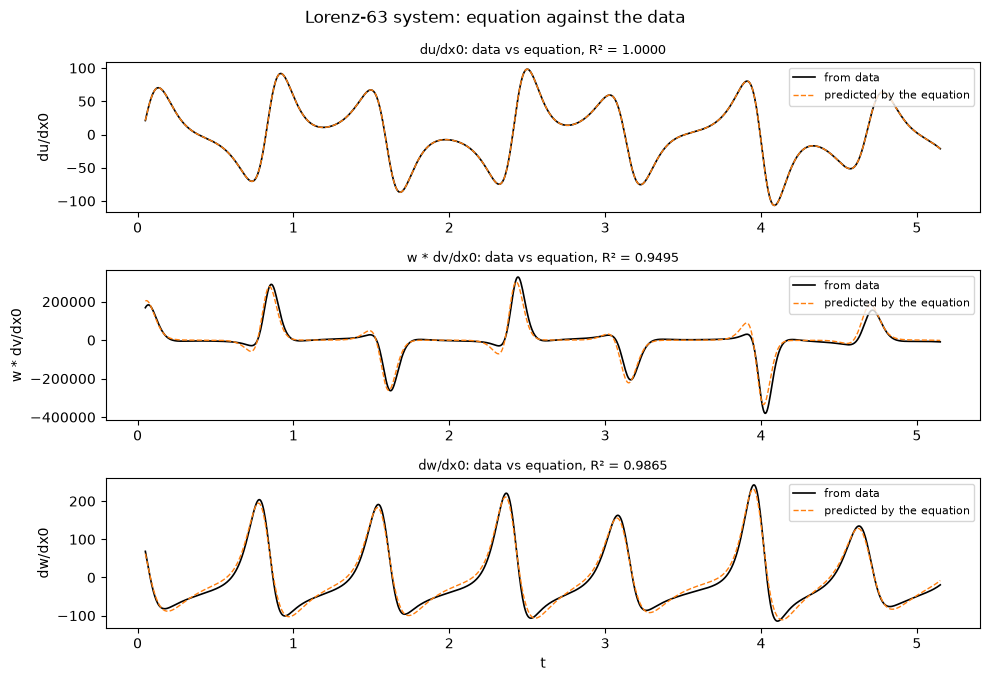

{'du/dx0{power: 1.0}': 1.0, 'w{power: 2.0} * dv/dx0{power: 1.0}': 0.9495, 'dw/dx0{power: 1.0}': 0.9865}


In [10]:
problem = datasets.load('lorenz')
search_cfg = resolve_for_problem(load_config('lorenz'), problem)
if rec['status'] == 'ok' and rec.get('selected'):
    fig, scores = plot_reconstruction(problem, rec['selected'], search_cfg)
    plt.show()
    print({k: round(v, 4) for k, v in scores.items()})

In [11]:
rec = cached_run('lorenz', variant='default', noise=5.0, seed=0)
print_run(rec)

ok fit 444 s (from cache)
[0]
     / 0.0026734701256784185 * x{power: 1.0, dim: 0.0} * v{power: 3.0} + 0.0 = du/dx0{power: 1.0}
     | 0.0772118261768402 * v{power: 3.0} + -0.003023816653426467 * w{power: 1.0} * v{power: 3.0} + 0.0 = dv/dx0{power: 1.0}
     \ 0.006040088072646525 * w{power: 3.0} * u{power: 1.0} + 0.0 = du/dx0{power: 1.0} * dw/dx0{power: 1.0}
[1]
     / 0.008260210926321624 * w{power: 3.0} + -6.963058357562189 * u{power: 2.0} + 5.9422259913225615 * v{power: 2.0} + 0.0 = v{power: 1.0} * du/dx0{power: 1.0}
     | -3.1884754242198525e-05 * w{power: 2.0} * u{power: 3.0} + 0.0 = dv/dx0{power: 1.0}
     \ 1.4467457491641718 * u{power: 2.0} + -0.15286465953226588 * w{power: 2.0} + 0.0 = dw/dx0{power: 1.0}
[2] <- compromise pick
     / 9.799798279107547 * v{power: 1.0} + -9.804734945304348 * u{power: 1.0} + 0.0 = du/dx0{power: 1.0}
     | 25.27394555728663 * u{power: 1.0} + -0.9420081286654454 * w{power: 1.0} * u{power: 1.0} + 0.0 = dv/dx0{power: 1.0}
     \ 0.00268371926822881